# Skin Lesion Classification — Improving Melanoma Recall
Follow-up to the [baseline](SkinLesions.ipynb). Same pipeline, one lever changed:
- **`WeightedRandomSampler`** instead of class-weighted loss. 
- Goal: reduce the ~14% of melanomas misclassified as benign `nv` (melanocytic nevi).

In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torchvision import transforms

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("Device :", device)   

PyTorch: 2.13.0
Device : mps


In [2]:
import random
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# Load Data and show the first image

DatasetDict({
    train: Dataset({
        features: ['image', 'image_id', 'lesion_id', 'dx', 'dx_type', 'age', 'sex', 'localization'],
        num_rows: 9577
    })
    validation: Dataset({
        features: ['image', 'image_id', 'lesion_id', 'dx', 'dx_type', 'age', 'sex', 'localization'],
        num_rows: 2492
    })
    test: Dataset({
        features: ['image', 'image_id', 'lesion_id', 'dx', 'dx_type', 'age', 'sex', 'localization'],
        num_rows: 1285
    })
})
dict_keys(['image', 'image_id', 'lesion_id', 'dx', 'dx_type', 'age', 'sex', 'localization'])


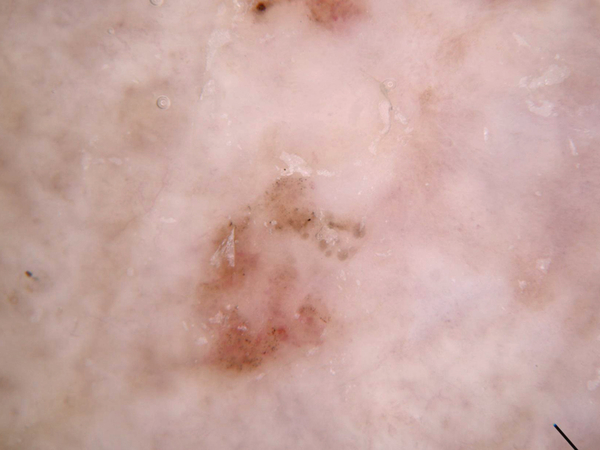

In [3]:
from datasets import load_dataset

ds = load_dataset("marmal88/skin_cancer")
print(ds)                 
print(ds["train"][0].keys())
ds["train"][0]["image"]   

# Load the Model

In [4]:
from torchvision.models import ResNet18_Weights

weights = ResNet18_Weights.DEFAULT
print("Model Weights:")
print(weights.transforms())

Model Weights:
ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


### We look at the distribution of labels in the training dataset

In [5]:
counts = pd.Series(ds["train"]["dx"]).value_counts()
counts

melanocytic_Nevi                 6405
melanoma                         1076
benign_keratosis-like_lesions    1048
basal_cell_carcinoma              487
actinic_keratoses                 315
vascular_lesions                  136
dermatofibroma                    110
Name: count, dtype: int64

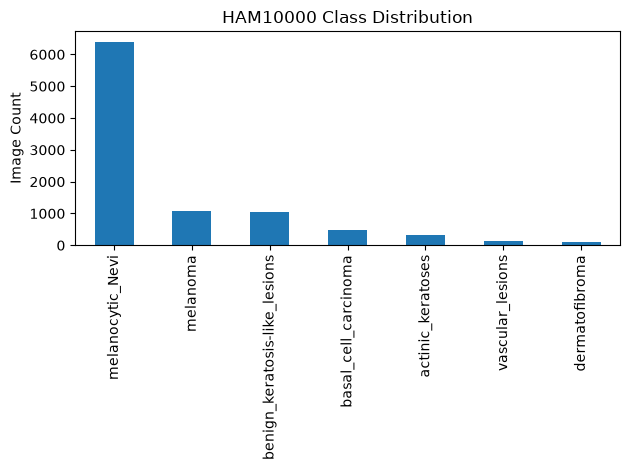

In [6]:
counts.plot(kind="bar", title="HAM10000 Class Distribution")
plt.ylabel("Image Count")
plt.tight_layout()
plt.show()

## Label-Mapping

In [7]:
classes = sorted(set(ds["train"]["dx"]))          
label2id = {c: i for i, c in enumerate(classes)}  
id2label = {i: c for c, i in label2id.items()}    
num_classes = len(classes)

print(num_classes, "Classes:", label2id)

7 Classes: {'actinic_keratoses': 0, 'basal_cell_carcinoma': 1, 'benign_keratosis-like_lesions': 2, 'dermatofibroma': 3, 'melanocytic_Nevi': 4, 'melanoma': 5, 'vascular_lesions': 6}


## Transforms

Each image must be resized to the same dimensions (224×224) and normalized to the same range of values that ResNet-18 is familiar with from its ImageNet training (hence these fixed mean/std values—they are the ImageNet standard, not arbitrary). During training, we also introduce slight random variations (flipping, brightness)—this is called augmentation and helps prevent the model from memorizing the data. We omit this during validation and testing because we want to measure performance accurately there.

In [8]:
weights = ResNet18_Weights.DEFAULT
cfg = weights.transforms()

IMAGENET_MEAN = cfg.mean
IMAGENET_STD  = cfg.std
IMG_SIZE      = cfg.crop_size[0]   
print(f" size={IMG_SIZE}, mean={IMAGENET_MEAN}, std={IMAGENET_STD}")

 size=224, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]


# Prepare Training Data -Pipeline

The [3, 224, 224] means: 3 color channels (RGB) × 224 height × 224 width — exactly the format that PyTorch models require as input.

In Compose, the order is crucial because each step processes the previous one. 

Image operations first (Resize, Flip, ColorJitter)—these operate on a PIL(Python Imaging Library) image.
Then ToTensor(), which converts the image to numbers.
Normalize() comes last—it performs calculations on the numbers and works only on a tensor, not on an image.

In [9]:
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),                                   
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

## Dataset class (applies the transforms to each image):

In [10]:
from torch.utils.data import Dataset

class HAMDataset(Dataset):
    def __init__(self, hf_split, transform):
        self.ds = hf_split
        self.transform = transform

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        item = self.ds[idx]
        image = item["image"].convert("RGB")
        label = label2id[item["dx"]]
        return self.transform(image), label

## DataLoader (groups into batches):

Introduce WeightedRandomSampler

In [11]:
from torch.utils.data import WeightedRandomSampler
from torch.utils.data import DataLoader
from collections import Counter

train_labels   = [label2id[dx] for dx in ds["train"]["dx"]]
class_count    = Counter(train_labels)
sample_weights = [1.0 / class_count[lbl] for lbl in train_labels]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_ds = HAMDataset(ds["train"],      train_tf)
val_ds   = HAMDataset(ds["validation"], eval_tf)
test_ds  = HAMDataset(ds["test"],       eval_tf)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=sampler,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=0)

## Sanity Check:

In [12]:
images, labels = next(iter(train_loader))
print("Image-Batch:", images.shape)   
print("Label-Batch :", labels.shape)   
print("Value range:", round(images.min().item(), 2), "bis", round(images.max().item(), 2))

Image-Batch: torch.Size([32, 3, 224, 224])
Label-Batch : torch.Size([32])
Value range: -2.12 bis 2.64


# Training
- Forward — Pass images through the model → Predictions
- Loss — Measure how inaccurate the predictions are (a number)
- zero_grad — Clear old “correction notes”
- Backward — Calculate the direction in which each weight should be adjusted to reduce the error (gradients)
- Step — Shift the weights a small amount in that direction

In [13]:
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights

weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)
model.fc = nn.Linear(model.fc.in_features, num_classes)   
model = model.to(device)                                  
print("Modell ready at:", device)

Modell ready at: mps


### Loss & Optimizer


In [14]:
criterion = nn.CrossEntropyLoss()          
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

## Training-Function

In [15]:
def train_one_epoch():
    model.train()                              # Training mode (Augmentation etc. active)
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)                # 1. Forward
        loss = criterion(outputs, labels)      # 2. Loss

        optimizer.zero_grad()                  # 3. zero_grad
        loss.backward()                        # 4. Backward
        optimizer.step()                       # 5. Step

        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total

In [16]:
@torch.no_grad()                               # Saves memory: no gradients required
def evaluate(loader):
    model.eval()                               # Analysis Mode (No Augmentation)
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total

In [17]:
EPOCHS = 5
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch()
    va_loss, va_acc = evaluate(val_loader)
    print(f"Epoch {epoch}/{EPOCHS}  "
          f"train: loss={tr_loss:.3f} acc={tr_acc:.3f}  |  "
          f"val: loss={va_loss:.3f} acc={va_acc:.3f}")

Epoch 1/5  train: loss=0.649 acc=0.769  |  val: loss=0.425 acc=0.846
Epoch 2/5  train: loss=0.449 acc=0.834  |  val: loss=0.334 acc=0.884
Epoch 3/5  train: loss=0.370 acc=0.864  |  val: loss=0.286 acc=0.885
Epoch 4/5  train: loss=0.293 acc=0.892  |  val: loss=0.243 acc=0.911
Epoch 5/5  train: loss=0.255 acc=0.907  |  val: loss=0.234 acc=0.915


In [18]:
torch.save(model.state_dict(), "resnet18_ham10000.pt")
# Load: model.load_state_dict(torch.load("resnet18_ham10000.pt", map_location=device))

## Validation

In [20]:
import torch
from collections import Counter
from sklearn.metrics import classification_report

model.eval()
y_true_t, y_pred_t = [], []
with torch.no_grad():
    for images, labels in val_loader:
        outputs = model(images.to(device))
        y_pred_t.extend(outputs.argmax(1).cpu().tolist())
        y_true_t.extend(labels.tolist())

print("What the Model predicts:", Counter(id2label[p] for p in y_pred_t))
print()
print(classification_report(y_true_t, y_pred_t, target_names=classes, digits=3))

What the Model predicts: Counter({'melanocytic_Nevi': 1689, 'benign_keratosis-like_lesions': 270, 'melanoma': 221, 'actinic_keratoses': 134, 'basal_cell_carcinoma': 118, 'vascular_lesions': 32, 'dermatofibroma': 28})

                               precision    recall  f1-score   support

            actinic_keratoses      0.590     0.963     0.731        82
         basal_cell_carcinoma      0.949     0.903     0.926       124
benign_keratosis-like_lesions      0.859     0.844     0.851       275
               dermatofibroma      1.000     0.933     0.966        30
             melanocytic_Nevi      0.950     0.963     0.957      1666
                     melanoma      0.864     0.682     0.762       280
             vascular_lesions      1.000     0.914     0.955        35

                     accuracy                          0.915      2492
                    macro avg      0.887     0.886     0.878      2492
                 weighted avg      0.920     0.915     0.914      2492

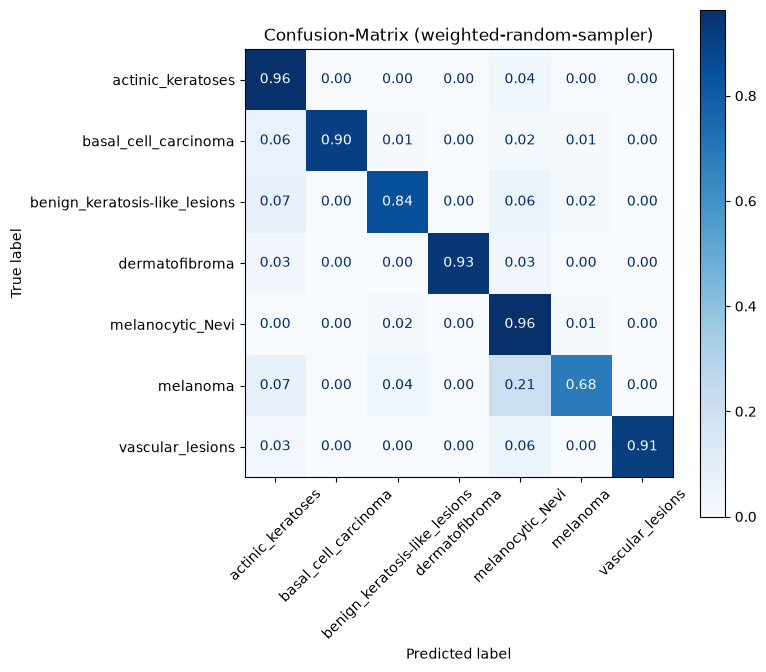

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(
    y_true_t, y_pred_t,
    display_labels=classes,
    xticks_rotation=45,
    normalize="true",        
    values_format=".2f",
    cmap="Blues",
    ax=ax,
)
plt.title("Confusion-Matrix (weighted-random-sampler)")
plt.tight_layout()
plt.show()

## Conclusion
Class weights make the model aggressive toward rare classes—it would rather call something “melanoma->dangerous” once too often, thereby pulling melanomas out of the nv corner (only 14% slip through), but at the cost of lower nv recall.

Sampler + normal loss makes the model more balanced/calibrated—it detects nv more accurately (0.96), but is less suspicious of melanomas → more of them slip through as “benign” (21%).

For the clinical goal of “never missing a melanoma,” aggressiveness is therefore the desired behavior—and the class-weighted loss delivers this better. The baseline wins.

## Hypothesis: 
Balanced sampling improves melanoma recall. 
Result (same seed): The rate of dangerous errors rose from 14% to 21%. 

Reason: The sampler calibrates the model better for nv, but makes it less sensitive to melanomas—the wrong trade-off for a screening objective. 

The class-weighted loss remains superior.